In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns



from matplotlib.patches import FancyArrowPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from src.data_models.caravanify import Caravanify, CaravanifyConfig

In [6]:
sns.set_context("paper", font_scale=1.3)

---

In [47]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/shapefiles",
    gauge_id_prefix="CH",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

caravan = Caravanify(config)

ids_for_training = caravan.get_all_gauge_ids()

gdf = caravan.get_shapefiles()
gdf = gdf[gdf["gauge_id"].isin(ids_for_training)]

gdf.head()

,gauge_id,geometry
2,CH_2009,"MULTIPOLYGON Z (((7.00197 46.37201 0, 7.00197 ..."
3,CH_2011,"POLYGON Z ((7.89701 46.41781 0, 7.89952 46.416..."
5,CH_2016,"POLYGON Z ((8.18842 47.48429 0, 8.18867 47.483..."
7,CH_2018,"POLYGON Z ((8.33544 47.42163 0, 8.33545 47.421..."
8,CH_2019,"POLYGON Z ((8.45045 46.76463 0, 8.44995 46.764..."


In [48]:
df = pd.read_csv(
    "/Users/cooper/Desktop/CAMELS-CH/clustering_results/cluster_assignments_shifted_refactor.csv"
)

df.head()

,gauge_id,cluster
0,CH_2009,0
1,CH_2011,0
2,CH_2016,10
3,CH_2018,0
4,CH_2019,0


In [49]:
gdf = gdf.merge(df[['gauge_id', 'cluster']], on='gauge_id', how='left')
gdf.head()

,gauge_id,geometry,cluster
0,CH_2009,"MULTIPOLYGON Z (((7.00197 46.37201 0, 7.00197 ...",0
1,CH_2011,"POLYGON Z ((7.89701 46.41781 0, 7.89952 46.416...",0
2,CH_2016,"POLYGON Z ((8.18842 47.48429 0, 8.18867 47.483...",10
3,CH_2018,"POLYGON Z ((8.33544 47.42163 0, 8.33545 47.421...",0
4,CH_2019,"POLYGON Z ((8.45045 46.76463 0, 8.44995 46.764...",0


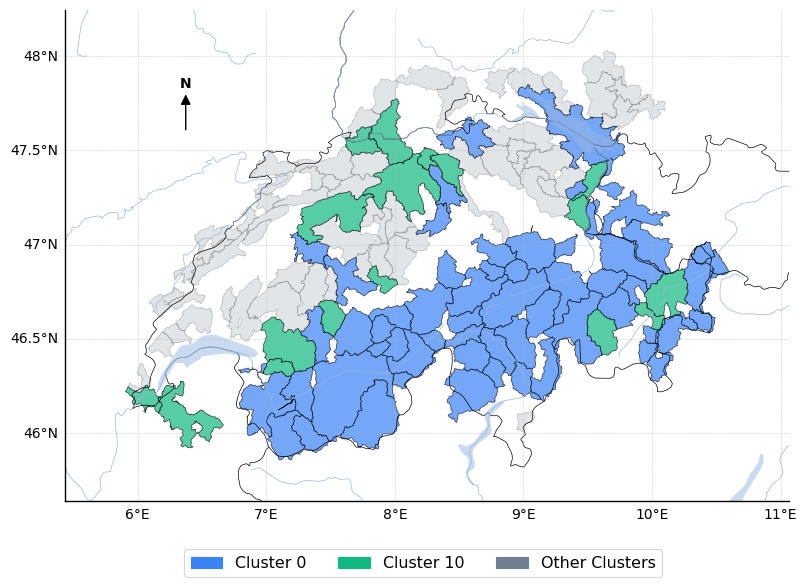

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define color mapping for clusters 0 and 10
cluster_color_map = {
    0: "#3B82F6",  # Vibrant slate-blue (leaning toward cornflower/azure)
    10: "#10B981"  # Fresh vibrant green (with a cool undertone)
}



# Create a color column based on cluster values
gdf["color"] = gdf["cluster"].apply(lambda x: cluster_color_map.get(x, "#708090"))

# Start plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Cartographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.0)
ax.add_feature(cfeature.OCEAN, alpha=0.0)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS, linewidth=0.5)

# Plot clusters 0 and 10
for cluster_value in [0, 10]:
    cluster_gdf = gdf[gdf["cluster"] == cluster_value]
    if not cluster_gdf.empty:
        cluster_gdf.plot(
            ax=ax,
            color=cluster_color_map[cluster_value],
            alpha=0.7,
            edgecolor="black",
            linewidth=0.5,
            transform=ccrs.PlateCarree()
        )

# Plot all other clusters in gray
other_gdf = gdf[~gdf["cluster"].isin([0, 10])]
if not other_gdf.empty:
    other_gdf.plot(
        ax=ax,
        color="#708090",
        alpha=0.2,
        edgecolor="black",
        linewidth=0.5,
        transform=ccrs.PlateCarree()
    )

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

# Spines
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

# North arrow
arrow_x, arrow_y = gdf.total_bounds[0] + 0.1 * (gdf.total_bounds[2] - gdf.total_bounds[0]), \
                   gdf.total_bounds[3] - 0.2 * (gdf.total_bounds[3] - gdf.total_bounds[1])
arrow_length = 0.1 * (gdf.total_bounds[3] - gdf.total_bounds[1])
north_arrow = FancyArrowPatch(
    (arrow_x, arrow_y),
    (arrow_x, arrow_y + arrow_length),
    transform=ccrs.PlateCarree(),
    color="black",
    linewidth=1,
    arrowstyle="-|>",
    mutation_scale=15,
)
ax.add_patch(north_arrow)
ax.text(
    arrow_x,
    arrow_y + arrow_length + 0.01 * (gdf.total_bounds[3] - gdf.total_bounds[1]),
    "N",
    transform=ccrs.PlateCarree(),
    ha="center",
    fontsize=10,
    fontweight="bold",
)

# Legend
legend_elements = [
    mpatches.Patch(color=color, label=f"Cluster {cluster}")
    for cluster, color in cluster_color_map.items()
]
legend_elements.append(mpatches.Patch(color="#708090", label="Other Clusters"))

# Map extent with buffer
buffer = 0.1
xmin, ymin, xmax, ymax = gdf.total_bounds
x_buffer = (xmax - xmin) * buffer
y_buffer = (ymax - ymin) * buffer
ax.set_extent([xmin - x_buffer, xmax + x_buffer, ymin - y_buffer, ymax + y_buffer], crs=ccrs.PlateCarree())

plt.tight_layout()

# Legend outside
fig.legend(handles=legend_elements,
           loc="lower center",
           bbox_to_anchor=(0.5, 0.01),
           ncol=3,
           frameon=True)

plt.subplots_adjust(bottom=0.15)

plt.savefig("/Users/cooper/Desktop/CAMELS-CH/images/Clustering/switzerland_cluaster_0_10_basins.png", dpi=300, bbox_inches='tight')
plt.show()
